In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1. Exponentially Weighted Moving Average

In [12]:
# dataset (toy)

# For reproducibility
np.random.seed(42)

# Generate 200 daily dates
dates = pd.date_range(start="2026-01-01", periods=200, freq="D")

# Time index
t = np.arange(200)

# Create a realistic seasonal time series
monthly_cycle = 10 * np.sin(2 * np.pi * t / 30)   # Monthly rise & fall
weekly_cycle = 5 * np.sin(2 * np.pi * t / 7)      # Small weekly variation
trend = 0.3 * t                                  # Slight upward trend
noise = np.random.normal(0, 2, 200)               # Random noise

# Final values
values = 100 + trend + monthly_cycle + weekly_cycle + noise

# Create DataFrame
df = pd.DataFrame({
    "Date": dates,
    "Value": np.round(values, 2)
})

# Display first few rows
print(df.head())

        Date   Value
0 2026-01-01  100.99
1 2026-01-02  106.01
2 2026-01-03  110.84
3 2026-01-04  111.99
4 2026-01-05  105.99


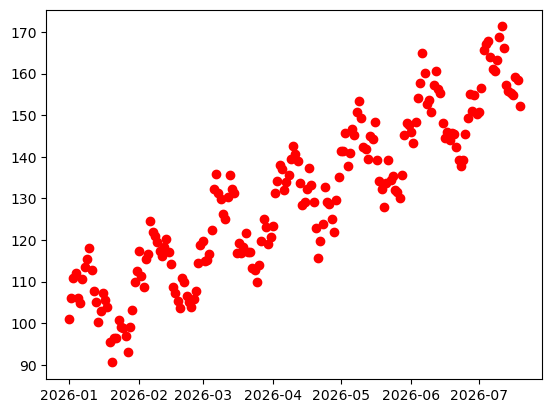

In [14]:
plt.scatter(df["Date"] , df["Value"] , color = 'red')

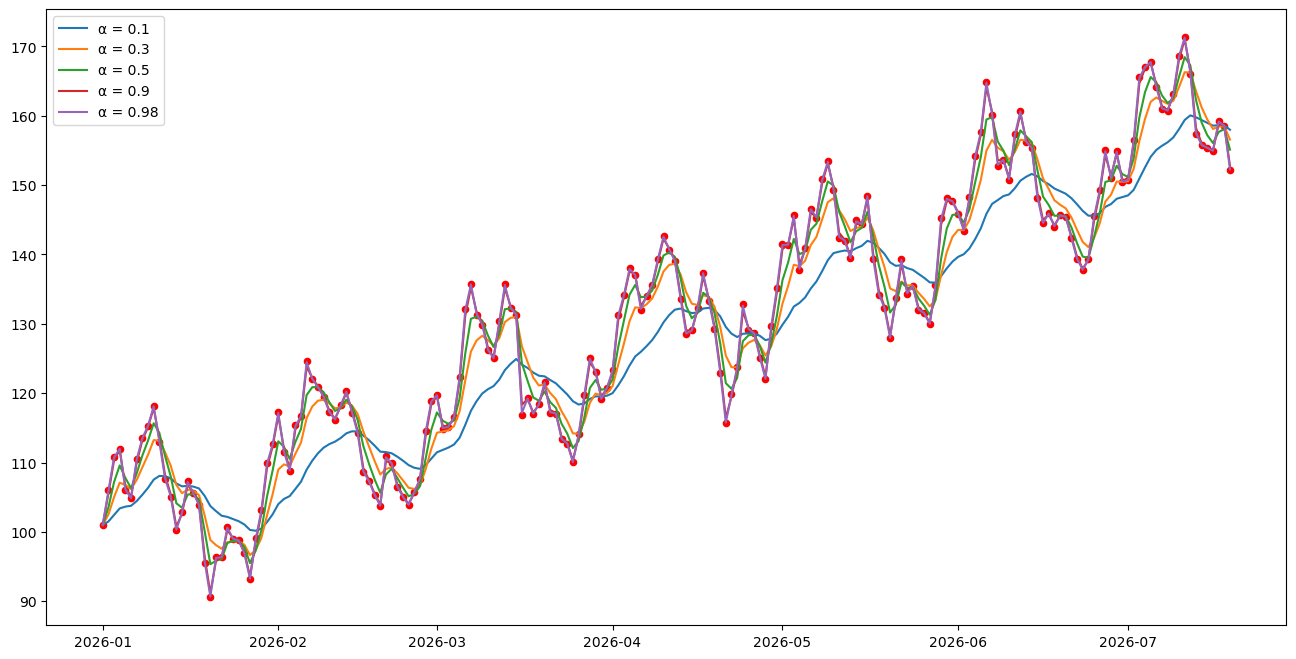

In [27]:
plt.figure(figsize=(16,8))

plt.scatter(df["Date"], df["Value"], color="red", s=20)

for alpha in [0.1, 0.3, 0.5, 0.9, 0.98]:
    df[f"EWMA_{alpha}"] = df["Value"].ewm(alpha=alpha, adjust=False).mean()
    plt.plot(df["Date"], df[f"EWMA_{alpha}"], label=f"α = {alpha}")

plt.legend()
plt.show()